# Butina Clustering 

# Setup Code
## Environment

In [1]:
### use brd4

import sys

print(sys.executable)

/home/oskar/anaconda3/envs/brd4/bin/python


## Imports

In [2]:
### Standard imports
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from rdkit import RDLogger
from tqdm import tqdm

## Jupyter Settings

In [3]:
### Random seed - using the same seed for robustness
SEED = 0
np.random.seed(SEED)

### NumPy arrays - floats
np.set_printoptions(
    precision=2,  # round values
    suppress=True,
)  # avoid scientific notation

### pandas DataFrames
pd.set_option("display.float_format", "{:.2f}".format)  # Round to 2 decimal places

### Initialize tqdm for pandas
tqdm.pandas()

### Suppress RDKit logs
RDLogger.DisableLog("rdApp.*")

### Re-enable logging if needed
# RDLogger.EnableLog('rdApp.*')

## Utils
- [`utils/pd_mol.py`](../utils/pd_mol.py) contains individual functions for processing rdkit mol objects in pandas DataFrames. 
- The utility class [`MorganSimilarity`](../utils/similarity_sali.py) will be used to calculate Morgan fingerprints (features). 

In [4]:
### Add the utils directory to the path
sys.path.append(os.path.abspath("../utils"))

from pd_mol import render_mol
import pd_mol
import similarity_sali

# Data
To ensure reproducibility `01_brd4_all_inhibitors.pkl` generated [here](../01_eda/01_pre_process.ipynb) is used for this analysis. They are described by (columns):
- `ID`: string - unique identifier from `ChEMBL`
- `Mol`: rdkit.Chem.rdchem.Mol - standardized inhibitor structure 
- `pIC50`: float - quantitative activity (negative logarithm of the half maximal inhibitory concentration in `mol / L`). 
- `active`: float - 1.00 (active), 0.00 (inactive)

2920


,Mol,pIC50,active
ID,,,
CHEMBL1097107,,6.25,NaN
CHEMBL1232461,,7.01,1.00
CHEMBL1233528,,6.92,1.00

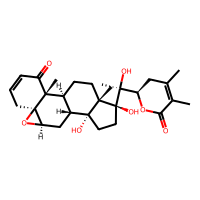
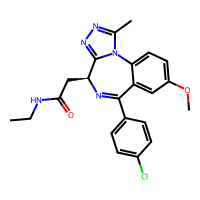
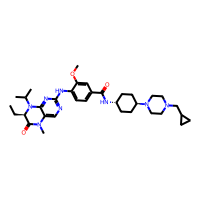

In [5]:
df = pd.read_pickle("../data/01_brd4_all_inhibitors.pkl")
df.set_index("ID", inplace=True)
print(len(df))
render_mol(df.head(3))

# Bemis-Murcko Scaffolds

A molecule's Bemis-Murcko scaffold is a simplified representation: [G. W. Bemis and M. A. Murcko, *J. Med. Chem*. **1996**, *39*, 15, 2887–2893](https://pubs.acs.org/doi/10.1021/jm9602928). 

Atoms and bonds are classified as:

- Fragments: One fragment is any kind of ring system. 
- Linkers: Bonds connecting fragments. 
- Side chains: Neither fragments or linkers. 

For this analysis:
- Side chains are stripped. 
- Bond orders are ignored.
- The element type of atoms are ignored. 

The utility function [`similarity_sali.get_bemis_murcko`](../utils/similarity_sali.py) generates the scaffolds from RDKit mol objects and assigns cluster IDs. 

In [6]:
### Bemis-Murcko clustering
df = similarity_sali.get_bemis_murcko(df, return_smiles=False, return_cluster=True)

MurckoScaffold.MakeScaffoldGeneric


100%|██████████| 2920/2920 [00:01<00:00, 2447.45it/s]


MurckoScaffold.GetScaffoldForMol


100%|██████████| 2920/2920 [00:00<00:00, 6479.52it/s]


sanitize=True (Chem.SanitizeMol):


...

100%|██████████| 2920/2920 [00:01<00:00, 1623.06it/s]


largest_frag=False (rdMolStandardize.FragmentParent):
remove_charge=False (rdMolStandardize.Uncharger().uncharge):
tautomerize=False (rdMolStandardize.CanonicalTautomer)
remove_stereo=False (rdMolStandardize.StereoParent):
cal_2D_coord_default=True (rdDepictor.Compute2DCoords):


100%|██████████| 2920/2920 [00:00<00:00, 4384.37it/s]


cal_2D_coord_deep=False (rdCoordGen.AddCoords):
Chem.MolToSmiles


100%|██████████| 2920/2920 [00:00<00:00, 7010.49it/s]


,Mol,pIC50,active,BM_mol,BM_cluster
ID,,,,,
CHEMBL4476857,,6.15,0.00,,385
CHEMBL5432311,,5.95,0.00,,628
CHEMBL4114296,,7.60,1.00,,148

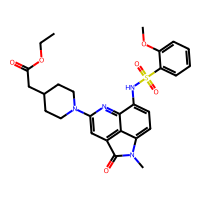
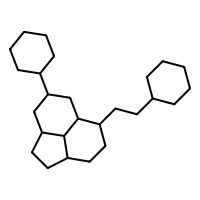
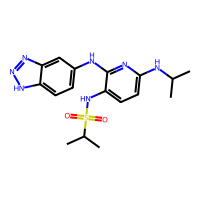
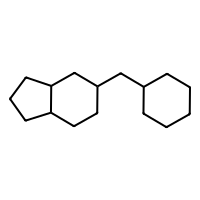
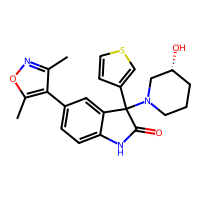
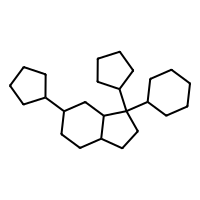

In [7]:
### Inspection
render_mol(df.sample(3))

,BM_scaffold,count,pIC50_median,pIC50_mean,pIC50_std
BM_cluster,,,,,
5,,62,5.77,5.84,0.57
36,,54,5.79,5.75,0.62
149,,53,7.20,7.17,0.51
1,,52,6.98,6.77,0.81
40,,50,6.05,6.00,0.46

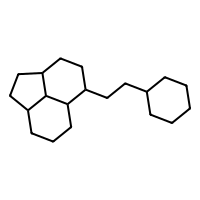
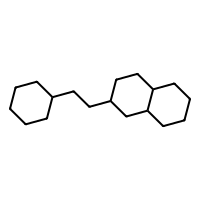
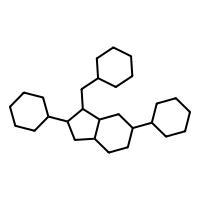
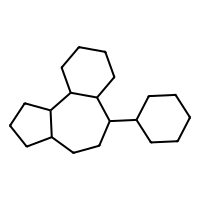
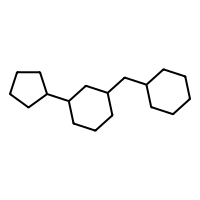

In [8]:
BM_cluster_df = (
    df.groupby("BM_cluster")
    .agg(
        BM_scaffold=("BM_mol", "first"), 
        count=("pIC50", "size"),
        pIC50_median=("pIC50", "median"),
        pIC50_mean=("pIC50", "mean"),
        pIC50_std=("pIC50", "std"),
    )
    .sort_values("count", ascending=False)
)

render_mol(BM_cluster_df.head(5))

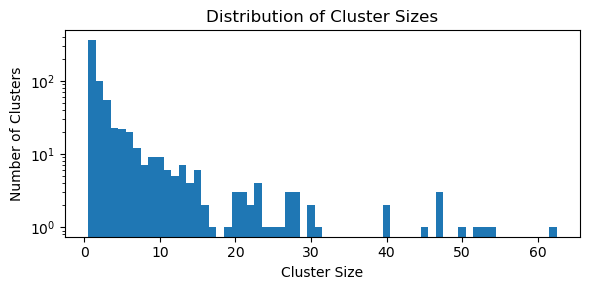

In [9]:
### Plot cluster distribution
plt.figure(figsize=(6, 3))
plt.hist(
    df['BM_cluster'].value_counts(), 
    bins=range(1, df['BM_cluster'].value_counts().max() + 2), 
    align='left')

plt.xlabel("Cluster Size")
plt.ylabel("Number of Clusters")
plt.title("Distribution of Cluster Sizes")
plt.yscale("log")
plt.tight_layout()
plt.show()


# Butina Centroids for Bemis-Murcko Clusters

Butina clustering is used to display representative members of Bemis-Murcko Clusters. 

The utility function [`butina_clustering()`](../utils/similarity_sali.py) requires a distance matrix and relies on `rdkit.ML.Cluster.Butina`. Three new columns are created:
- `Cluster_ID`: The cluster ID assigned to each molecule. Cluster are inherently
    sorted by cluster size. 
- `is_centroid`: Boolean indicating if the molecule is a centroid of a cluster.
- `is_singleton`: Boolean indicating if the molecule is a singleton. All singletons are automatically centroids.

*Note:* Jaccard distances are used. 

## Distance Matrix
Throughout this repository Morgan fingerprints are used as molecular descriptors. The utility class [`MorganSimilarity`](../utils/similarity_sali.py) contains the methods 
- `.get_morgan_fingerprint()` and 
- `.get_tanimoto_similarity_matrix()` 

In [10]:
### Create a class instance
morgan = similarity_sali.MorganSimilarity(df, nBits=2048, radius=3, useChirality=True)

### Generate Morgan fingerprints as list of bitvectors
fp_list = morgan.get_morgan_fingerprint()

### Convert to DataFrame for inspection
dist_mat = morgan.get_tanimoto_similarity_matrix(return_jaccard_distances=True)

dist_mat

array([[0.  , 0.95, 0.94, ..., 0.93, 0.94, 0.95],
       [0.95, 0.  , 0.87, ..., 0.91, 0.9 , 0.93],
       [0.94, 0.87, 0.  , ..., 0.89, 0.92, 0.94],
       ...,
       [0.93, 0.91, 0.89, ..., 0.  , 0.92, 0.9 ],
       [0.94, 0.9 , 0.92, ..., 0.92, 0.  , 0.9 ],
       [0.95, 0.93, 0.94, ..., 0.9 , 0.9 , 0.  ]], shape=(2920, 2920))

## Butina Loop

In [11]:
### Number of Butina centroids per Bemis-Murcko cluster to inspect
n_centroids = 5

### Jaccard threshold for Butina clustering
butina_threshold = 0.4

### Create column for Butina centroids
centroid_cols = [f"Butina_centroid_{i+1}" for i in range(n_centroids)]
BM_cluster_df[centroid_cols] = None

### Loop through each Bemis-Murcko cluster
for cluster_id in tqdm(BM_cluster_df.index):
    
    ### Mask for cluster BM members
    cluster_mask = df['BM_cluster'] == cluster_id

    ### Positional index for BM cluster members 
    member_pos = np.where(cluster_mask)[0]

    ### Butina clustering
    _, centroids_df = similarity_sali.butina_clustering(
        # Subset DataFrame for BM cluster members
        df.loc[cluster_mask].copy(),
        # Subset distance matrix for BM cluster members 
        dist_mat[np.ix_(member_pos, member_pos)], 
        butina_threshold, 
        analyze=False, 
        inspect_n_members=0)

    ### Select the first n_centroids
    if len(centroids_df) > n_centroids:
        selected = centroids_df.iloc[:n_centroids, 1].tolist()
    else:
        selected = centroids_df.iloc[:, 1].tolist()
    
    ### Assign the selected centroids to the DataFrame
    BM_cluster_df.loc[cluster_id, centroid_cols[:len(selected)]] = selected

100%|██████████| 689/689 [00:03<00:00, 180.13it/s]


,BM_scaffold,count,pIC50_median,pIC50_mean,pIC50_std,Butina_centroid_1,Butina_centroid_2,Butina_centroid_3,Butina_centroid_4,Butina_centroid_5
BM_cluster,,,,,,,,,,
5,,62,5.77,5.84,0.57,,,,,
36,,54,5.79,5.75,0.62,,,,,
149,,53,7.20,7.17,0.51,,,,,
1,,52,6.98,6.77,0.81,,,,,
40,,50,6.05,6.00,0.46,,,,,
102,,47,6.85,6.74,0.65,,,,,
28,,47,7.04,6.91,0.94,,,,,
12,,47,6.22,6.25,0.94,,,,,
175,,45,6.85,6.73,0.54,,,,,

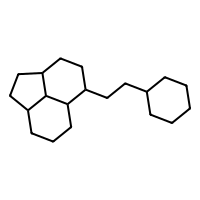
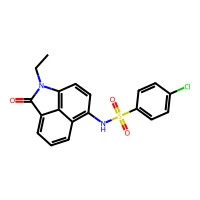
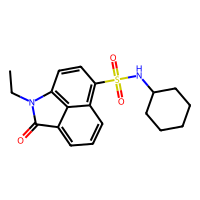
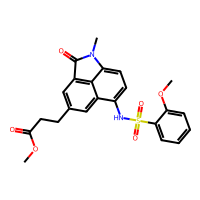
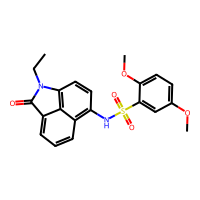
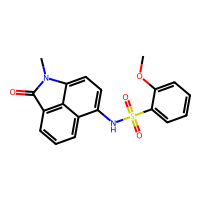
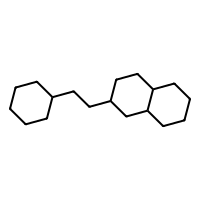
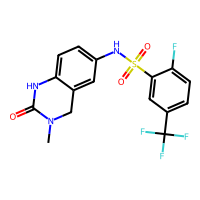
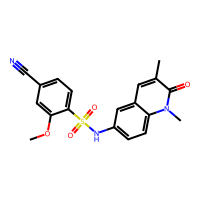
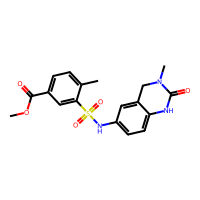
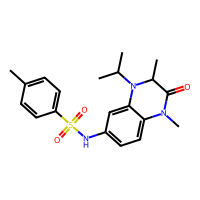
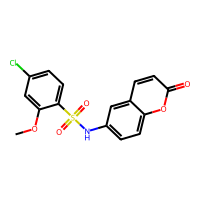
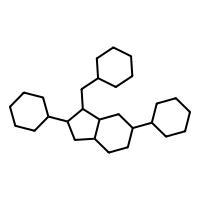
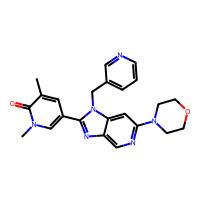
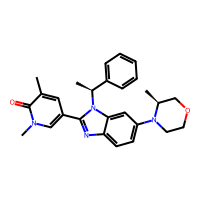
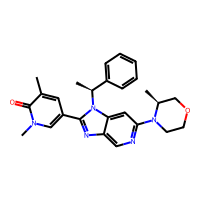
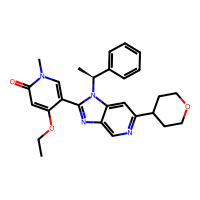
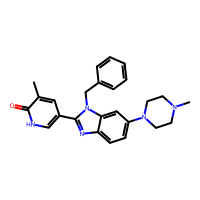
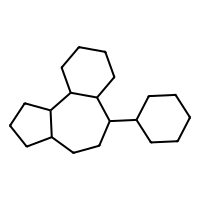
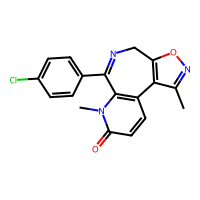
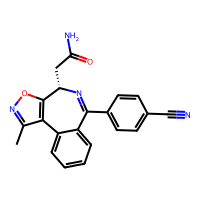
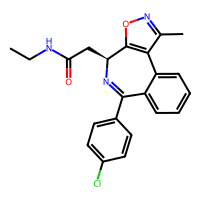
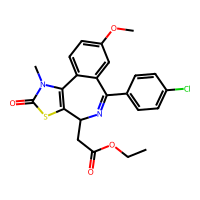
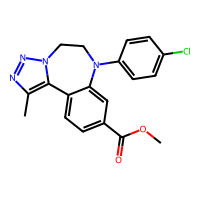
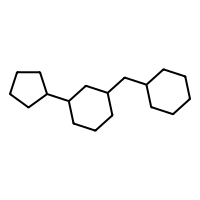
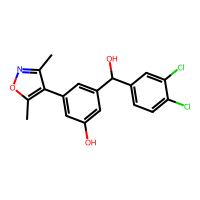
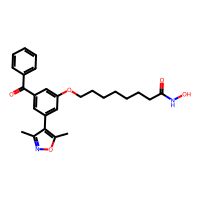
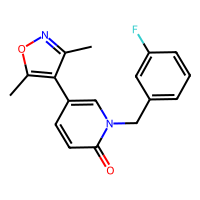
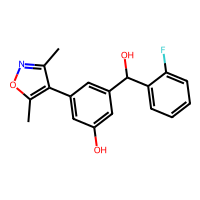
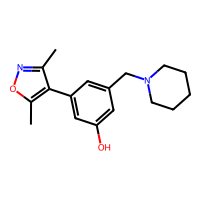
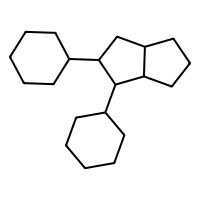
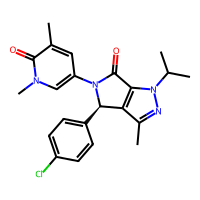
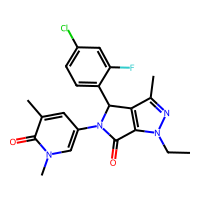
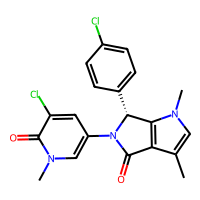
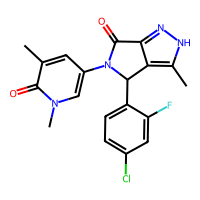
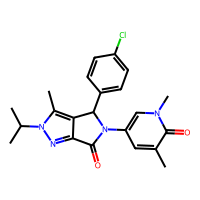
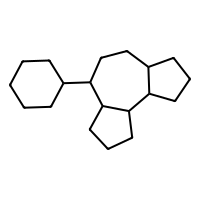
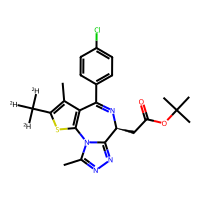
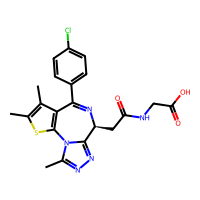
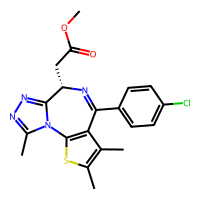
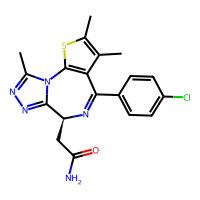
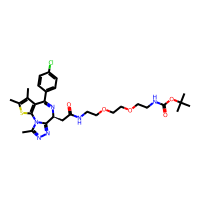
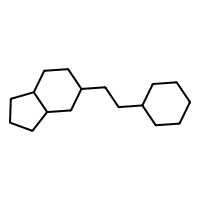
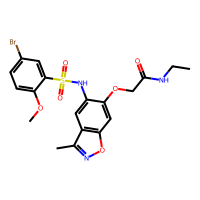
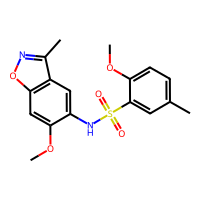
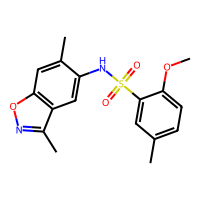
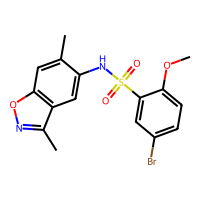
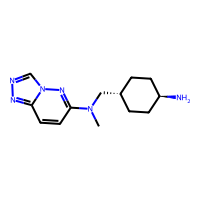
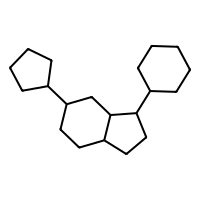
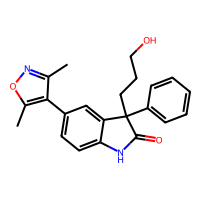
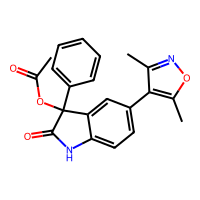
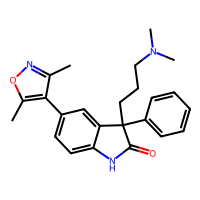
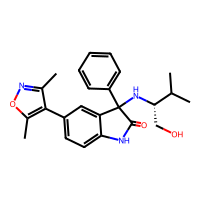
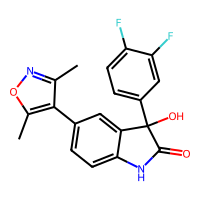
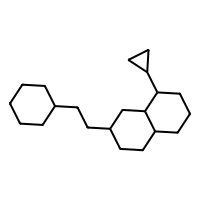
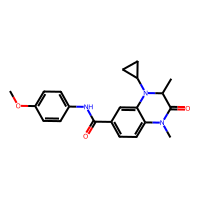
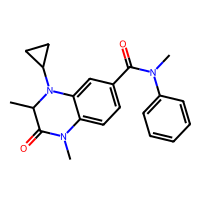
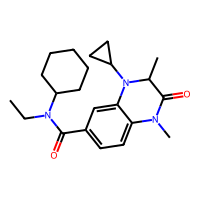
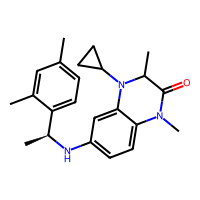
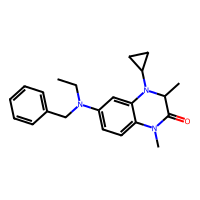

In [12]:
render_mol(BM_cluster_df.head(10))

# Sandbox

In [13]:
### Add the utils directory to the path
import importlib

import similarity_sali  # 🔹 Import the full module
importlib.reload(similarity_sali)  # 🔁 Reload the file

from similarity_sali import MorganSimilarity  # ✅ Now this works



# Appendix - Butina Clustering (full data set)

Attempts to perform Butina clustering on the entire data set were not satisfying. 

The utility function [`butina_clustering()`](../utils/similarity_sali.py) requires a distance matrix and relies on `rdkit.ML.Cluster.Butina`. Three new columns are created:
- `Cluster_ID`: The cluster ID assigned to each molecule. Cluster are inherently
    sorted by cluster size. 
- `is_centroid`: Boolean indicating if the molecule is a centroid of a cluster.
- `is_singleton`: Boolean indicating if the molecule is a singleton. All singletons are automatically centroids.

*Note:* Jaccard distances are used. 

1242 clusters.
912 sigletons.
121 compounds in the largest cluster.
Number of clusters with more than 5 compound: 81
Number of clusters with more than 20 compound: 13


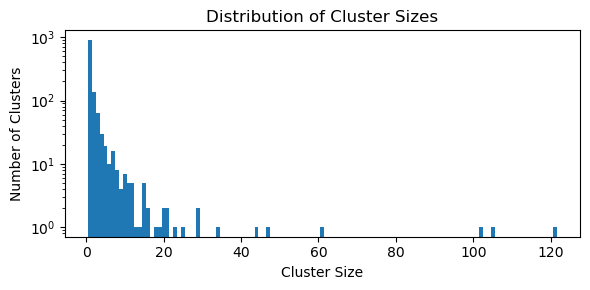

,Size,Centroid,Member_1,Member_2,Member_3,Member_4,Member_5
0,121,,,,,,
1,105,,,,,,
2,102,,,,,,
3,61,,,,,,
4,47,,,,,,

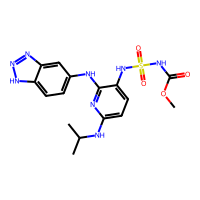
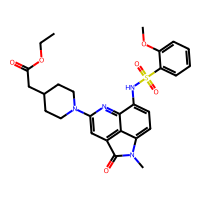
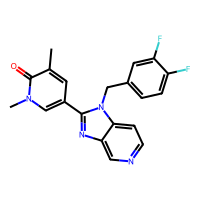
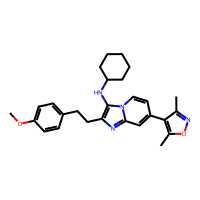
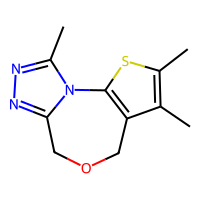
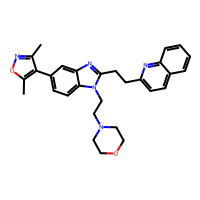
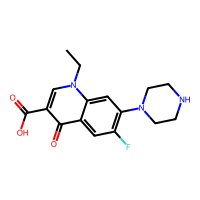
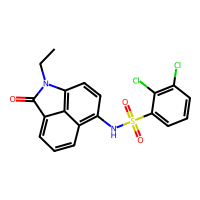
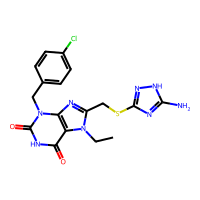
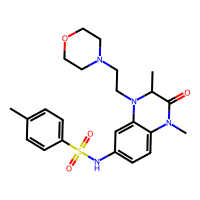
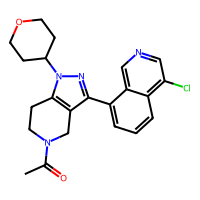
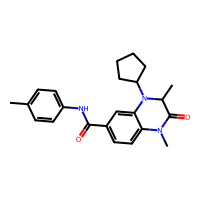
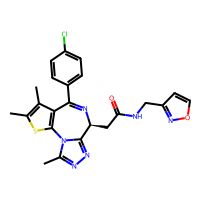
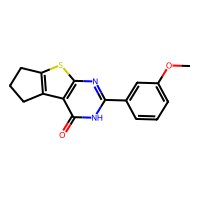
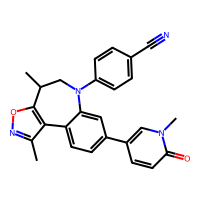
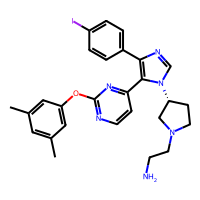
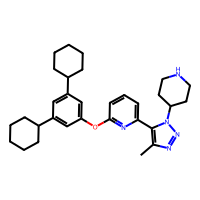
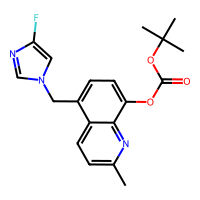
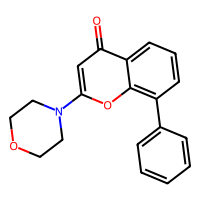
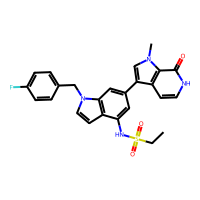
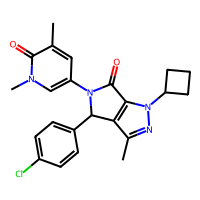
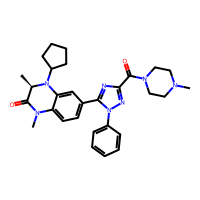
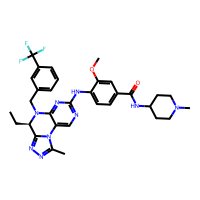
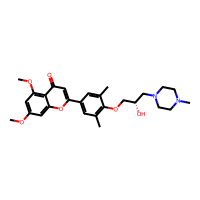
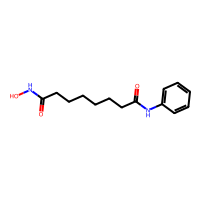
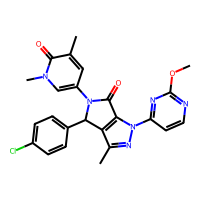
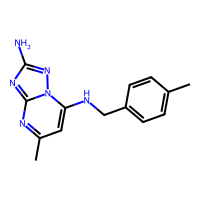
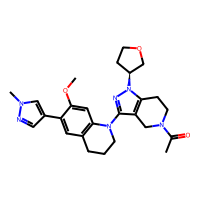
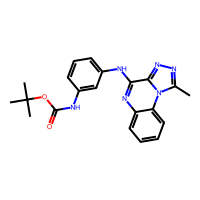
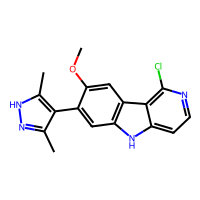

In [14]:
### Define the threshold (Jaccard distance)
threshold = 0.30

### Butina clustering
butina_df, clusters_df = similarity_sali.butina_clustering(df, dist_mat, threshold, analyze=True)

render_mol(clusters_df.head())